# Paper Airplane DOE Notebook
## 2^2 Factorial Design for Paper Airplanes Design of Experiments

For this Tutorial 9, we will demonstrate a blocking design for a 2^2 experiment.  

**For your own Tutorial 9, use 2 factors at 2 levels and find your own experimental response measurements for Time of Flight.** 

### Objective
Study how two factors affect **flight distance**:

- **A: Wingspan** (`-1 = narrow`, `+1 = wide`)
- **C: Launch angle** (`-1 = shallow at ~25 degrees`, `+1 = steep at 45 degrees`)

### Response
- **Flight distance** (in meters)

For the demonstration DOE, we will use "The Buzz" type of paper airplane.  For your own you can use any design from:   https://www.foldnfly.com/#/1-1-1-1-1-1-1-1-2-1 

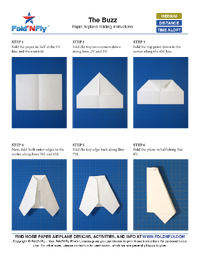  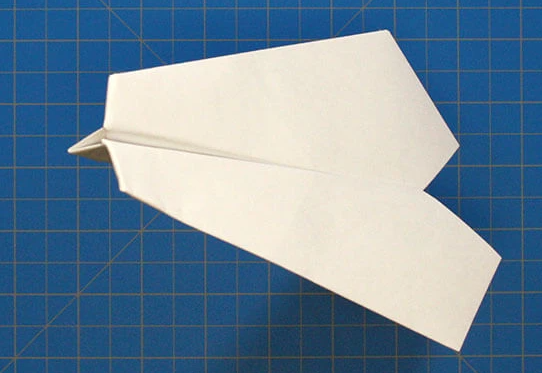

In [1]:
%reset

Once deleted, variables cannot be recovered. Proceed (y/[n])?  y


## Step 1: Import libraries and set up coded 2^ factorial design

We use:

- `pandas` for the data table
- `numpy` for calculations
- `statsmodels` for the factorial model
- `matplotlib` 


In [2]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

Create the coded 2^2 factorial design

The standard treatment combinations are shown below in coded form.


In [3]:
# Standard 2^2 factorial design in coded units
df = pd.DataFrame({
    "Run": [1,2,3,4],
    "A":   [-1, 1,-1, 1],
    "C":   [-1,-1,+1,+1]
})

df

,Run,A,C
0,1,-1,-1
1,2,1,-1
2,3,-1,1
3,4,1,1


## Step 2: Experimental Runs for a single 2^2 full factorial screening design

We threw the airplane 4 times under the designed conditions and in random order and measured the flight distances. 

In [4]:
distance = [4.1,4.9,4.4,5.8]

dfa = df.copy()
dfa["Distance"] = distance

dfa

,Run,A,C,Distance
0,1,-1,-1,4.1
1,2,1,-1,4.9
2,3,-1,1,4.4
3,4,1,1,5.8


## Procedure

Construct the paper airplane according to the factor levels for each run.

For each run, we will:
- Configure the airplane according to A and C.
- Throw the airplane once, using a single thrower.
- Measure and record the flight distance.

- Record the results as data table.


## Step 3: Fit the full 2^2 factorial model and Show the summary of the fitted model results and the ANOVA table

In [6]:
model = ols("Distance ~ A + C", data=dfa)
results=model.fit()
print(results.summary2())

                 Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.837   
Dependent Variable: Distance         AIC:                2.1745  
Date:               2026-03-30 17:30 BIC:                0.3334  
No. Observations:   4                Log-Likelihood:     1.9127  
Df Model:           2                F-statistic:        8.722   
Df Residuals:       1                Prob (F-statistic): 0.233   
R-squared:          0.946            Scale:              0.090000
-------------------------------------------------------------------
            Coef.    Std.Err.      t      P>|t|     [0.025   0.975]
-------------------------------------------------------------------
Intercept   4.8000     0.1500   32.0000   0.0199    2.8941   6.7059
A           0.5500     0.1500    3.6667   0.1695   -1.3559   2.4559
C           0.3000     0.1500    2.0000   0.2952   -1.6059   2.2059
-----------------------------------------------------------------
Omnibus:       

C:\Users\User\anaconda3\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 4 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


In [7]:
from statsmodels.stats.anova import anova_lm

anova_lm(results)

,df,sum_sq,mean_sq,F,PR(>F)
A,1.0,1.21,1.21,13.444444,0.169501
C,1.0,0.36,0.36,4.000000,0.295167
Residual,1.0,0.09,0.09,NaN,NaN


## Step 4:  Repeat the full factorial, using a second thrower.  Fit the model and show the summary and ANOVA.

Fit the model using the 8 observations with A, C, and A*C.

## Questions:
1. Explain why repeating on the second thrower provides MSE and inferential statistics.
2. Interpret the model.
3. Interpret the SSError and the MSE. 

In [8]:
import pandas as pd

# Factor settings
A = [-1,1,-1,1]*2
C = [-1,-1,1,1]*2

# Block indicator (thrower)
Block = ["T1"]*4 + ["T2"]*4

# Distance responses
Distance = [
4.1,4.9,4.4,5.8,  # Thrower 1
4.3,5.1,4.4,5.9  # Thrower 2
]

# Create dataframe
df_block = pd.DataFrame({
"A":A,
"C":C,
"Block":Block,
"Distance":Distance
})

df_block


,A,C,Block,Distance
0,-1,-1,T1,4.1
1,1,-1,T1,4.9
2,-1,1,T1,4.4
3,1,1,T1,5.8
4,-1,-1,T2,4.3
5,1,-1,T2,5.1
6,-1,1,T2,4.4
7,1,1,T2,5.9


In [9]:
from statsmodels.formula.api import ols

model2 = ols("Distance ~ A*C", data=df_block)
results2 = model2.fit()

print(results2.summary2())


                 Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.976   
Dependent Variable: Distance         AIC:                -10.7413
Date:               2026-03-30 17:32 BIC:                -10.4235
No. Observations:   8                Log-Likelihood:     9.3706  
Df Model:           3                F-statistic:        97.59   
Df Residuals:       4                Prob (F-statistic): 0.000339
R-squared:          0.987            Scale:              0.011250
-------------------------------------------------------------------
            Coef.    Std.Err.      t       P>|t|    [0.025   0.975]
-------------------------------------------------------------------
Intercept   4.8625     0.0375   129.6667   0.0000   4.7584   4.9666
A           0.5625     0.0375    15.0000   0.0001   0.4584   0.6666
C           0.2625     0.0375     7.0000   0.0022   0.1584   0.3666
A:C         0.1625     0.0375     4.3333   0.0123   0.0584   0.2666
-------------

In [33]:
from statsmodels.stats.anova import anova_lm

anova_lm(results2)

,df,sum_sq,mean_sq,F,PR(>F)
A,1.0,2.53125,2.53125,225.000000,0.000115
C,1.0,0.55125,0.55125,49.000000,0.002192
A:C,1.0,0.21125,0.21125,18.777778,0.012317
Residual,4.0,0.04500,0.01125,NaN,NaN


Question 5:
1. Before, in the first experiment, we had 4 data points and 4 parameters to estimate. There was no "leftover" data to calculate error. By adding a second thrower, we now have 8 observations, leaving 4 degrees of freedom for the residuals 8-4.
2. intercept 4.86 average flight distance, A is 0.5625 increasing wingspan increase 0.5625 flight distance, C is 0.2625, increasing launch angle increase 0.2625 flight distance, A:C positive interaction of both in increasing flight distance (small)
3. SSE is 0.045 which is squared deviation of 8 throws that are unexplained, and MSE is SSE/dof = 0.045 / 4 = 0.01125 is the variance sigma^2 of error 

## Step 5:  Now treat the second thrower as a block effect.

Refit the model with the second thrower, now including a Block effect for the Thrower. 

You can consder the above repeating the full factorial in a block, and now taking that blcok effect into account.  Fit the model based on the factors of interest and the block as a single effect.  

Without blocking, the difference between throwers would be absorbed into the residual error.

## Questions:
1. Explain why we would block based on two different throwers. 

In [10]:
from statsmodels.formula.api import ols

model3 = ols("Distance ~ A*C+Block", data=df_block)
results3 = model3.fit()

print(results3.summary2())

                 Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.990    
Dependent Variable: Distance         AIC:                -18.2262 
Date:               2026-03-30 17:36 BIC:                -17.8290 
No. Observations:   8                Log-Likelihood:     14.113   
Df Model:           4                F-statistic:        181.4    
Df Residuals:       3                Prob (F-statistic): 0.000659 
R-squared:          0.996            Scale:              0.0045833
-------------------------------------------------------------------
                Coef.   Std.Err.     t      P>|t|    [0.025  0.975]
-------------------------------------------------------------------
Intercept       4.8000    0.0339  141.8014  0.0000   4.6923  4.9077
Block[T.T2]     0.1250    0.0479    2.6112  0.0796  -0.0273  0.2773
A               0.5625    0.0239   23.5005  0.0002   0.4863  0.6387
C               0.2625    0.0239   10.9669  0.0016   0.1863  0.3387
A:C   

In [11]:
from statsmodels.stats.anova import anova_lm

anova_lm(results3)

,df,sum_sq,mean_sq,F,PR(>F)
Block,1.0,0.03125,0.031250,6.818182,0.079605
A,1.0,2.53125,2.531250,552.272727,0.000169
C,1.0,0.55125,0.551250,120.272727,0.001623
A:C,1.0,0.21125,0.211250,46.090909,0.006533
Residual,3.0,0.01375,0.004583,NaN,NaN


## To Show: Block effect for Box Plots

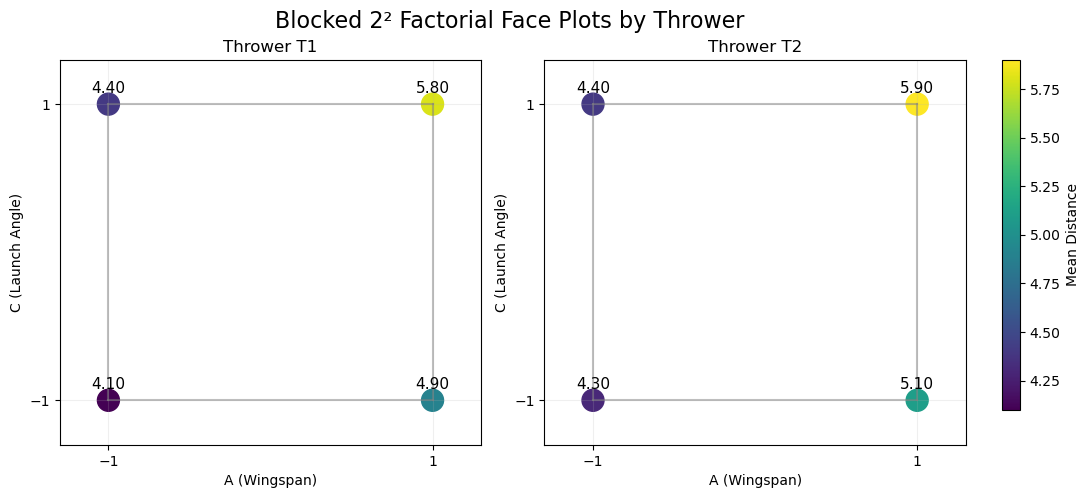

In [12]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

fig, axes = plt.subplots(1, 2, figsize=(12,5))
fig.suptitle("Blocked 2² Factorial Face Plots by Thrower", fontsize=16)

all_vals = (
    df_block.groupby(["Block","A","C"], as_index=False)["Distance"]
    .mean()["Distance"]
)

shared_norm = plt.Normalize(all_vals.min(), all_vals.max())
cmap = cm.viridis

for ax, block_name in zip(axes, ["T1","T2"]):

    face_df = (
        df_block[df_block["Block"]==block_name]
        .groupby(["A","C"], as_index=False)["Distance"]
        .mean()
    )

    # square
    ax.plot([-1,1],[-1,-1], color="gray", alpha=0.5)
    ax.plot([-1,1],[1,1], color="gray", alpha=0.5)
    ax.plot([-1,-1],[-1,1], color="gray", alpha=0.5)
    ax.plot([1,1],[-1,1], color="gray", alpha=0.5)

    sc = ax.scatter(
        face_df["A"], face_df["C"],
        s=250,
        c=face_df["Distance"],
        cmap=cmap,
        norm=shared_norm
    )

    for _, row in face_df.iterrows():
        ax.text(
            row["A"], row["C"] + 0.08,
            f'{row["Distance"]:.2f}',
            ha="center", fontsize=11
        )

    ax.set_xlim(-1.3,1.3)
    ax.set_ylim(-1.3,1.3)
    ax.set_xticks([-1,1])
    ax.set_yticks([-1,1])
    ax.set_xlabel("A (Wingspan)")
    ax.set_ylabel("C (Launch Angle)")
    ax.set_title(f"Thrower {block_name}")
    ax.grid(alpha=0.2)

# Leave room on the right for a separate colorbar axis
fig.subplots_adjust(right=0.88, wspace=0.15)

# Dedicated colorbar axis: [left, bottom, width, height]
cax = fig.add_axes([0.91, 0.18, 0.015, 0.70])
cbar = fig.colorbar(
    cm.ScalarMappable(norm=shared_norm, cmap=cmap),
    cax=cax
)
cbar.set_label("Mean Distance")

plt.show()


Question:

The goal of blocking is to isolate nuisance variables, which are variables that we now that might affect the result if they are variables that are not the primary focus of the study. THis allows the variance (noise) to decrease across the study by pulling the variance into the block. 